
# Stock Prices ML — Level 1 Tasks (Task 1 & Task 2)


- **Task 1 (Data Preprocessing)**: handle missing values, encode categorical columns, scale numeric features, and split into train/test.
- **Task 2 (Simple Linear Regression)**: build and evaluate a linear regression model to predict the **`close`** price.



In [1]:

# === Task 0: Setup & Imports ===
import numpy as np
import pandas as pd


In [2]:

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer


In [3]:

from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

import matplotlib.pyplot as plt

# pd.set_option('display.max_columns', None)


## Task 1 — Data Preprocessing

### 1.1 Load the dataset

In [5]:
df = pd.read_csv('stock_prices_data_set.csv')


FileNotFoundError: [Errno 2] No such file or directory: 'stock_prices_data_set.csv'

# analyze shape of dataset

In [ ]:
print("Shape:", df.shape)


Shape: (497472, 7)


# show first 5 rows 

In [ ]:
df.head()


,symbol,date,open,high,low,close,volume
0,AAL,2014-01-02,25.0700,25.8200,25.0600,25.3600,8998943
1,AAPL,2014-01-02,79.3828,79.5756,78.8601,79.0185,58791957
2,AAP,2014-01-02,110.3600,111.8800,109.2900,109.7400,542711
3,ABBV,2014-01-02,52.1200,52.3300,51.5200,51.9800,4569061
4,ABC,2014-01-02,70.1100,70.2300,69.4800,69.8900,1148391


# show data types of all the columns

In [ ]:
df.dtypes

symbol     object
date       object
open      float64
high      float64
low       float64
close     float64
volume      int64
dtype: object

### 1.2 Basic structure & parse dates

# Convert 'date' to datetime and create time features (helps models learn seasonality/temporal patterns)

In [ ]:


if 'date' in df.columns:
    df['date'] = pd.to_datetime(df['date'])
    df['year'] = df['date'].dt.year
    df['month'] = df['date'].dt.month
    df['day'] = df['date'].dt.day
    df['dayofweek'] = df['date'].dt.dayofweek  # Monday=0, Sunday=6



In [ ]:
print(df.dtypes)


symbol               object
date         datetime64[ns]
open                float64
high                float64
low                 float64
close               float64
volume                int64
year                  int32
month                 int32
day                   int32
dayofweek             int32
dtype: object


In [ ]:
df.head()

,symbol,date,open,high,low,close,volume,year,month,day,dayofweek
0,AAL,2014-01-02,25.0700,25.8200,25.0600,25.3600,8998943,2014,1,2,3
1,AAPL,2014-01-02,79.3828,79.5756,78.8601,79.0185,58791957,2014,1,2,3
2,AAP,2014-01-02,110.3600,111.8800,109.2900,109.7400,542711,2014,1,2,3
3,ABBV,2014-01-02,52.1200,52.3300,51.5200,51.9800,4569061,2014,1,2,3
4,ABC,2014-01-02,70.1100,70.2300,69.4800,69.8900,1148391,2014,1,2,3


### 1.3 Explore missing values

In [ ]:

missing = df.isna().sum().sort_values(ascending=False)
missing[missing > 0]


open    11
high     8
low      8
dtype: int64

### 1.4 Select target and features

# specify target column name

In [ ]:
target_col = "close"

# Drop rows where target is missing

In [ ]:
df = df.dropna(subset=[target_col])

# Features (all except 'close' and 'date')

In [ ]:

X = df.drop([target_col, "date"], axis=1)
y = df[target_col]



In [ ]:
print("Input Features shape:", X.shape)
print("Target shape:", y.shape)
X.head()


Input Features shape: (497472, 9)
Target shape: (497472,)


,symbol,open,high,low,volume,year,month,day,dayofweek
0,AAL,25.0700,25.8200,25.0600,8998943,2014,1,2,3
1,AAPL,79.3828,79.5756,78.8601,58791957,2014,1,2,3
2,AAP,110.3600,111.8800,109.2900,542711,2014,1,2,3
3,ABBV,52.1200,52.3300,51.5200,4569061,2014,1,2,3
4,ABC,70.1100,70.2300,69.4800,1148391,2014,1,2,3


### 1.5 Identify numeric & categorical columns

In [ ]:

numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object', 'category']).columns.tolist()




# showing the numerical and categorical features

In [ ]:
print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)

Numeric features: ['open', 'high', 'low', 'volume']
Categorical features: ['symbol']


### 1.6 splitting Input and target features into train and test data

In [ ]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# see the shapes of training and testing data

In [ ]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((397977, 9), (99495, 9), (397977,), (99495,))

### 1.7 Build preprocessing pipelines

# creating a pipeline for preprocessing numeric features.

In [ ]:

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])


# creating a pipeline for preprocessing categorical features.

In [ ]:
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])


# building a column transformer for numeric and categorical features

In [ ]:

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features),
    ],
    remainder='drop'  # drop any columns not specified
)


Processed shapes: (397977, 509) (99495, 509)


# Fit on train only data

In [ ]:

X_train_processed = preprocessor.fit_transform(X_train)


# transform on test data

In [ ]:
X_test_processed = preprocessor.transform(X_test)

# analyse the shape of train and test preproccessed data

In [ ]:
print("Processed shapes:", X_train_processed.shape, X_test_processed.shape)

Processed shapes: (397977, 509) (99495, 509)


## Task 2 — Simple Linear Regression Model

### 2.1 Build a pipeline: Preprocessing + Linear Regression

# making the object of linear regression

In [ ]:
linreg = LinearRegression()

In [ ]:
model = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('regressor', linreg)
])


# look at the model

In [ ]:
model

,steps,"[('preprocess', ...), ('regressor', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


### 2.2 Train the model on training data

In [ ]:
model.fit(X_train, y_train)

,steps,"[('preprocess', ...), ('regressor', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


### 2.3 Evaluate the model on test data

# first predict on test data

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

# print the evalution metrics result

In [ ]:
print(f"R-squared: {r2}")
print(f"MSE: {mse}")
print(f"RMSE: {rmse}")


R-squared: 0.9999495885068737
MSE: 0.522610841060074
RMSE: 0.7229182810387866


### 2.4 Predicted vs Actual plot

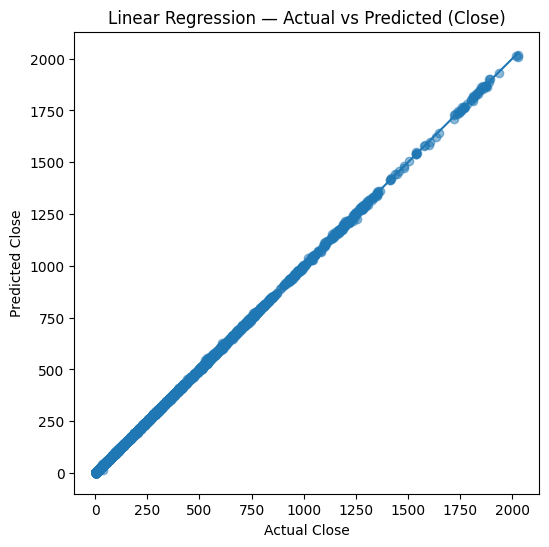

In [ ]:

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.xlabel("Actual Close")
plt.ylabel("Predicted Close")
plt.title("Linear Regression — Actual vs Predicted (Close)")
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val])
plt.show()
